#Introdução

A LH Nautical é uma empresa do setor de varejo náutico que vem enfrentando um rápido crescimento, trazendo consigo desafios relacionados à organização e confiabilidade dos dados. Atualmente, a empresa opera com dados descentralizados, inconsistentes e com baixa integração entre sistemas, dificultando a tomada de decisão baseada em dados.

Diante desse cenário, a diretoria busca evoluir para uma abordagem mais analítica, com foco em previsões de demanda, melhoria de margens e entendimento do comportamento dos clientes.

##Objetivo do Projeto

Este projeto tem como objetivo estruturar, tratar e analisar os dados disponíveis, transformando informações brutas em insights acionáveis para o negócio. Além disso, busca-se desenvolver análises preditivas e mecanismos simples de recomendação de produtos.

## Abordagem

Para atingir esses objetivos, o projeto foi dividido nas seguintes etapas:

- Análise Exploratória de Dados (EDA)
- Tratamento e padronização dos dados
- Análise de vendas e rentabilidade
- Análise de comportamento de clientes
- Previsão de demanda
-Sistema de recomendação de produtos

---

# Análise Exploratória Inicial (EDA) via SQL

**Objetivo:** Entender volume, distribuição e qualidade dos dados de vendas.

Neste primeiro passo, importamos o dataset `vendas_2023_2024.csv` para o banco **lh_nautics** e realizamos a análise exploratória utilizando SQL, sem qualquer tratamento de dados.

As análises realizadas incluíram:

- Número de linhas e colunas.
- Intervalo de datas (`sale_date`).
- Estatísticas da coluna `total` (min, max, média).

Os resultados foram:

- O dataset possui 9.901 registros cobrindo o período de 2023 a 2024.
- 6 colunas na tabela de vendas, sendo elas: `id`, `id_client`, `id_product`, `qtd`, `total` e `sale_date`
- A menor data que temos é 01-01-2023 e a maior data 31-12-2024.
- O menor valor de venda: R\$ 294,50
- O maior valor de venda: R\$ 2.222.973,00
- O valor médio de venda: R\$ 263.797,82

Com base na análise exploratória inicial, concluo que o dataset *vendas_2023_2024.csv* não é totalmente confiável para análises futuras sem tratamento prévio. Durante a importação dos dados em um SGBD, foram identificados diversos alertas indicando que algumas linhas não possuem dados para todas as colunas. Isso evidencia a presença de registros incompletos ou linhas totalmente vazias, comprometendo a qualidade dos dados.

Além disso, foi possível observar inconsistência no formato das datas, com registros em diferentes padrões (como dia/mês/ano, mês/dia/ano e ano/mês/
dia). Essa variação pode gerar erros ou interpretações incorretas em análises temporais. Em relação à coluna *total*, foram identificados possíveis outliers, com valores significativamente superiores à média.


# Normalização de Produtos

**Objetivo:** Padronizar categorias, converter valores numéricos e remover duplicatas no dataset `produtos_raw.csv`, tornando os dados consistentes para análise.

### Passos realizados:

1. Carregar o CSV `produtos_raw.csv`.
2. Padronizar os nomes das categorias em:
   - eletrônicos
   - propulsão
   - ancoragem
3. Converter valores numéricos (ex: preços e quantidades).
4. Remover duplicatas para garantir unicidade dos produtos.

In [ ]:
import pandas as pd

df_produtos = pd.read_csv("/produtos_raw.csv", sep=',')

# Tratamento campos numéricos
df_produtos['price'] = df_produtos['price'].str.replace('R$', '', regex=False)
df_produtos['price'] = df_produtos['price'].str.strip()
df_produtos['price'] = pd.to_numeric(df_produtos['price'])

# Tratamento categorias
df_produtos['actual_category'] = (df_produtos['actual_category']
    .str.lower()
    .str.strip()
    .str.replace(" ", "")
)

correcao_categorias = {
    'eletronicos': 'eletrônicos',
    'eletrônicos': 'eletrônicos',
    'eletrunicos': 'eletrônicos',
    'eletronicoz': 'eletrônicos',
    'eletroniscos': 'eletrônicos',

    'propulsao': 'propulsão',
    'propulção': 'propulsão',
    'prop': 'propulsão',
    'propulssão': 'propulsão',
    'propulsão': 'propulsão',
    'propução': 'propulsão',
    'propulçao': 'propulsão',
    'propulsam': 'propulsão',

    'ancoragem': 'ancoragem',
    'encoragem': 'ancoragem',
    'ancoraguem': 'ancoragem',
    'ancorajm': 'ancoragem',
    'ancorajem': 'ancoragem',
    'encoragi': 'ancoragem',
    'ancorajen': 'ancoragem',
    'ancoragen': 'ancoragem'
}

df_produtos['actual_category'] = df_produtos['actual_category'].replace(correcao_categorias)

# Removendo duplicados
print("O dataframe possuia " , df_produtos.duplicated().sum(), " registros duplicados")
df_produtos = df_produtos.drop_duplicates()

O dataframe possuia  7  registros duplicados


Essa limpeza é fundamental para as próximas análises, especialmente para identificar prejuízos e analisar comportamento de clientes.

# Custos de Importação (Tratamento de JSON)

**Objetivo:** Transformar o arquivo `custos_importacao.json` em um CSV estruturado, organizado em colunas:  
`product_id`, `product_name`, `category`, `start_date`, `usd_price`.

### Passos realizados:

1. Carregar o JSON.
2. Extrair os campos relevantes e normalizar os dados aninhados.
3. Converter datas e valores numéricos.
4. Salvar como CSV para uso nas análises financeiras futuras.

In [ ]:
import pandas as pd

df_custos_importacao = pd.read_json("/custos_importacao.json")

#Tratamento de historic_data para colunas individuais de start_date e usd_price
df_explode = df_custos_importacao.explode('historic_data')

df_custos_normalizado = pd.json_normalize(df_explode['historic_data'])

df_final = pd.concat([df_explode[['product_id', 'product_name', 'category']].reset_index(drop=True),
                      df_custos_normalizado.reset_index(drop=True)], axis=1)
#Tratamento das datas
df_final['start_date'] = pd.to_datetime(df_final['start_date'], format='%d/%m/%Y')

#Convertendo para um CSV
df_final.to_csv("custos_importacao_tratado.csv", index=False)

# Identificação de Prejuízos por Produto

**Objetivo:**  
Identificar produtos vendidos abaixo do custo real em BRL, considerando a cotação diária do dólar (dados do Bacen).


### Obtenção e tratamento do câmbio diário (Python)

In [ ]:
import requests

# Requisição à API do Bacen
url = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    "CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)"
    "?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'"
    "&$top=10000&$format=json"
)

response = requests.get(url)
data = response.json()

# Transformar em DataFrame
df_cambio = pd.DataFrame(data['value'])
df_cambio['data'] = pd.to_datetime(df_cambio['dataHoraCotacao']).dt.date

# Média da cotação por dia
df_cambio = df_cambio.groupby('data')['cotacaoVenda'].mean().reset_index()
df_cambio.rename(columns={'data': 'sale_date', 'cotacaoVenda': 'exchange_rate'}, inplace=True)

# Salvar CSV para uso no banco
df_cambio.to_csv("cambio.csv", index=False)

Os dados de cambio.csv foram exportados ao banco de dados onde já estavam os outros dados tratados referente a vendas e custos de importação.
Com a ajuda de consultas SQL foi possível identificar os produtos com os maiores prejuízos, então a tabela obtida pelas consultas SQL foi exportada para um CSV para que pudessemos criar um gráfico para melhor visualização desses dados.

### Visualização dos produtos com maior prejuízo (Python)

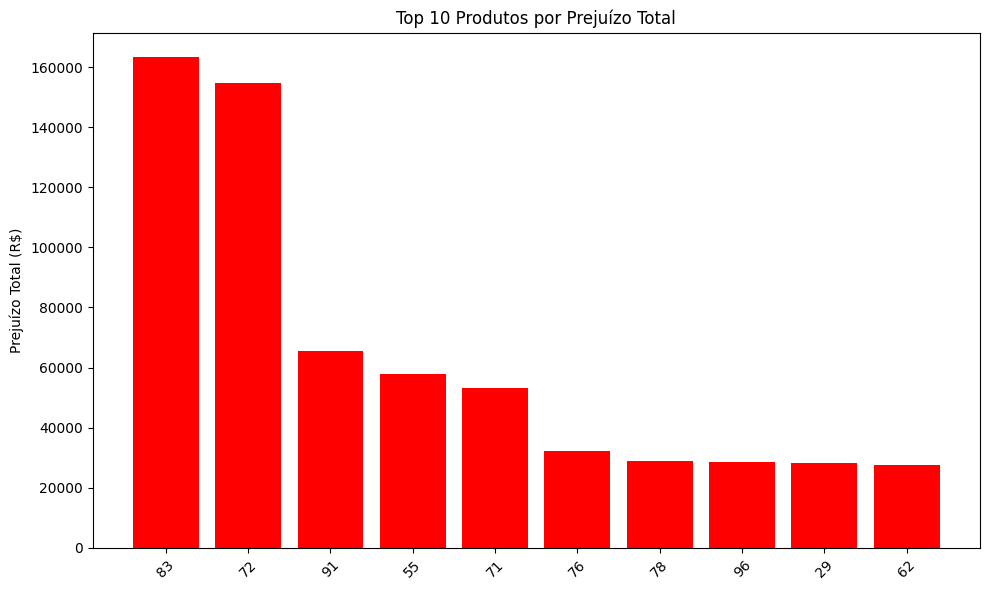

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("/produtos_prejuizo.csv", sep=";")
df.columns = df.columns.str.replace('"', '').str.strip()

# Converter colunas numéricas
colunas_numericas = ["receita_total", "prejuizo_total", "percentual_perda"]
for col in colunas_numericas:
    df[col] = df[col].astype(str).str.replace(",", ".")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Filtrar apenas produtos com prejuízo
df = df[df["prejuizo_total"] > 0]

# Gráfico 1: Top 10 Prejuízo Total
top10_prejuizo = df.sort_values("prejuizo_total", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_prejuizo["id_product"].astype(str), top10_prejuizo["prejuizo_total"], color='red')
plt.xticks(rotation=45)
plt.ylabel("Prejuízo Total (R$)")
plt.title("Top 10 Produtos por Prejuízo Total")
plt.tight_layout()
plt.show()

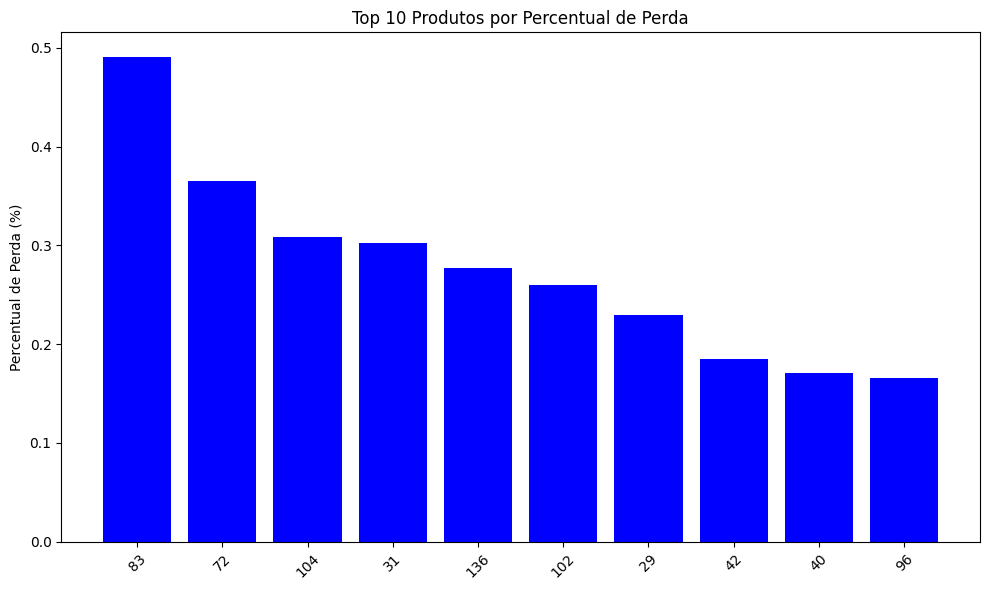

In [ ]:

# 3. Gráfico 2: Top 10 Percentual de Perda
top10_percentual = df.sort_values("percentual_perda", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_percentual["id_product"].astype(str), top10_percentual["percentual_perda"]*100, color='blue')
plt.xticks(rotation=45)
plt.ylabel("Percentual de Perda (%)")
plt.title("Top 10 Produtos por Percentual de Perda")
plt.tight_layout()
plt.show()

* Produto com maior prejuízo absoluto e maior percentual de perda: 83
* Focar no top 10 produtos que deram prejuízo total ou percentual nos ajuda a ter melhor visualização dos dados em gráfico.

###Considerações finais
Ao final de análise é possível notar que há dois produtos que se destacam com os maiores prejuízos absolutos e com os maiores percentuais de perda:

* Produto de id 83: Motor Diesel Yanmar Dash Nitro 184HP
* Produto de id 72: Motor de Popa Volvo Hydro Dash 256HP

Seria interessante revisar a estratégia de precificação desses dois produtos com maior prejuízo.




# Análise de Clientes Fiéis

**Objetivo:**  
Identificar os clientes mais fiéis e de maior valor, considerando ticket médio, diversidade de categorias e frequência de compra.  
Isso permite entender quais produtos atraem clientes de elite e replicar estratégias para outros segmentos.

### Passos realizados:
Com a ajuda de consultas SQL foi possível identificar e calcular indicadores por cliente:
* Faturamento Total
* Frequência de compras
* Ticket Médio = Faturamento Total / Frequência
* Diversidade de Categorias (quantidade de categorias distintas compradas)

In [ ]:
df_clientes_fieis = pd.read_csv('/clientes_fieis.csv', sep=';')

# Converter valores
df_clientes_fieis['ticket_medio'] = (
    df_clientes_fieis['ticket_medio']
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

df_clientes_fieis.head(10)

,id_client,full_name,diferente_categorias,total_gasto,total_vendas,ticket_medio
0,47,Gabriela Barros Lacerda,3,"64003343,75",190,336859.703947
1,42,MÃ¡rcia Figueiredo,3,"72187369,50",222,325168.331081
2,9,Lucas Guedes Cunha Lopes,3,"66788855,35",218,306370.896101
3,22,Daniela Borges Vieira Farias MendonÃ§a,3,"59581398,75",198,300916.155303
4,2,Fernanda Azevedo Soares Nunes Vieira,3,"65652931,35",220,298422.415227
5,28,Bianca Rodrigues,3,"60826837,25",204,298170.770833
6,46,Ana Silva Costa Farias Coelho,3,"59126834,35",199,297119.770603
7,38,Mateus Antunes,3,"57093331,15",195,292786.313590
8,36,Francisca Ribeiro Pinheiro,3,"62791038,15",215,292051.340233
9,5,Pedro Freitas,3,"58592802,70",202,290063.379703


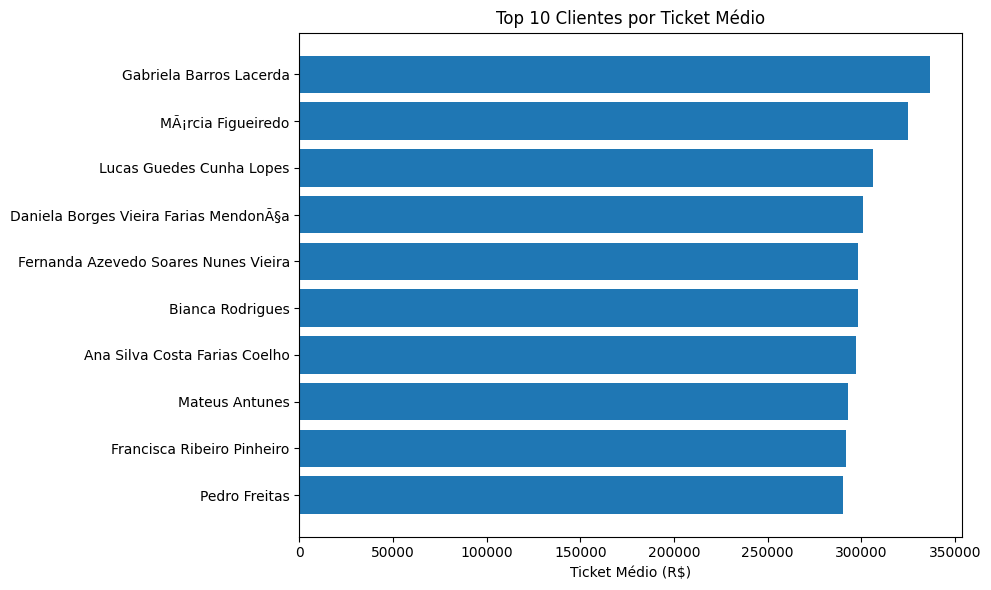

In [ ]:
# Ordenar do menor pro maior para melhor visualização no gráfico
top10 = top10.sort_values('ticket_medio', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top10['full_name'], top10['ticket_medio'])

plt.xlabel("Ticket Médio (R$)")
plt.title("Top 10 Clientes por Ticket Médio")

plt.tight_layout()
plt.show()

### Resultados obtidos pela análise

**Categoria mais comprada pelo Top 10 clientes:**  
- **Propulsão** (maior quantidade total de itens comprados)

### Explicação do processo de tratamento de dados e análise

1. **Limpeza das categorias:**  
   - Utilizei o Python (pandas) para padronizar os nomes das categorias no campo `actual_category`.  
   - Unifiquei grafias diferentes (ex: `"ancoraj"` → `"ancoragem"`, `"propulsao"` → `"propulsão"`).

2. **Filtragem por diversidade mínima:**  
   - No SQL, usei `HAVING COUNT(DISTINCT p.actual_category) >= 3` para garantir que o cliente comprou produtos de pelo menos 3 categorias diferentes.

3. **Contagem de itens apenas para os Top 10:**  
   - Criei uma **subquery** no SQL para selecionar os 10 clientes com maior ticket médio e diversidade mínima, e depois calculei a quantidade total de itens por categoria **apenas para esse grupo**.

A criação de um programa de fidelidade ou de pontuação para clientes fiéis se mostra promissora após essa análise.

# Análise de Vendas por Dia da Semana

**Objetivo:**  
Identificar o dia da semana com menor média de vendas, considerando **todos os dias do período**, inclusive aqueles em que não houve vendas. Isso ajuda a tomar decisões sobre operação da loja e estoque.

In [ ]:
df_media_diaria_vendas = pd.read_csv('/content/media_vendas_diaria.csv', sep=';')
df_media_diaria_vendas.head()

,dia_semana,media_vendas
0,Domingo,"3319503,57"
1,Segunda-feira,"3465137,71"
2,Quarta-feira,"3535265,63"
3,Quinta-feira,"3626232,44"
4,Terça-feira,"3627045,76"


### Resultados da análise

Dia da semana com menor média de vendas:

* Domingo
* Média histórica: R$ 3.319.503,57

Observação: Esses valores já consideram os dias sem vendas (zerados), garantindo uma média fiel à operação.

Para calcular a média de vendas por dia da semana de forma precisa, utilizamos um calendário completo que inclui todos os dias do período analisado. Nos dias em que não houve vendas, atribuíamos o valor zero. Dessa forma, a média considera tanto os dias com vendas quanto os dias sem movimentação, evitando que os resultados fiquem distorcidos. Sem esse procedimento, apenas os dias com transações seriam contabilizados, o que inflaria artificialmente a média e poderia levar a interpretações incorretas sobre o desempenho da loja ao longo da semana.


# Previsão de Demanda – Motor de Popa Yamaha Evo Dash 155HP

**Objetivo:**  
Construir um modelo baseline simples que estime as vendas diárias do produto "Motor de Popa Yamaha Evo Dash 155HP" para Janeiro de 2024, permitindo melhor planejamento de estoque.

### Passo 1 - Preparação dos dados (Python)

In [ ]:
from sklearn.metrics import mean_absolute_error

df_vendas = pd.read_csv('/content/vendas_tratadas.csv')
df_produtos = pd.read_csv('/content/produtos_tratados.csv')

# converter data foi necessário para podermos trabalhar com funções específicas de datas
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'])

# aqui foi necessário fazer um merge de vendas com produtos,
# pois apenas nesse csv que encontramos o nome do produto
df = df_vendas.merge(
    df_produtos,
    left_on='id_product',
    right_on='code',
    how='left'
)

# manter só colunas necessárias pois aqui trabalharemos só com as informações contidas nelas
# isso reduz a complexidade do dataframe
df = df[['sale_date', 'name', 'qtd']]

# filtrar produto
produto_analisado = "Motor de Popa Yamaha Evo Dash 155HP"
df_produto = df[df['name'] == produto_analisado].copy()

# agrupar vendas por dia
df_daily = df_produto.groupby('sale_date')['qtd'].sum().reset_index()

# criar calendário completo
full_dates = pd.date_range(
    start=df_daily['sale_date'].min(),
    end=df_daily['sale_date'].max()
)

df_daily = df_daily.set_index('sale_date').reindex(full_dates, fill_value=0)
df_daily = df_daily.rename_axis('date').reset_index()

### Passo 2 - Separar treino e teste

In [ ]:
train = df_daily[df_daily['date'] <= '2023-12-31'].copy()
test = df_daily[df_daily['date'] >= '2024-01-01'].copy()

### Passo 3 - Modelo baseline - Média movel 7 dias

In [ ]:
history = train[['date', 'qtd']].copy()
predictions = []

for i in range(len(test)):
    last_7_days = history['qtd'].iloc[-7:]
    pred = last_7_days.mean()
    predictions.append(pred)
    new_row = pd.DataFrame({'date':[test.iloc[i]['date']], 'qtd':[pred]})
    history = pd.concat([history, new_row], ignore_index=True)

test['prediction'] = predictions

# Avaliação do modelo
mae = mean_absolute_error(test['qtd'], test['prediction'])
print("MAE:", mae)

MAE: 0.9307228915662651


### Passo 4 - Previsão primeira semana de Janeiro de 2024

In [ ]:
week1 = test[(test['date'] >= '2024-01-01') & (test['date'] <= '2024-01-07')]
total_previsto = round(week1['prediction'].sum())
print("Total previsto primeira semana:", total_previsto)

Total previsto primeira semana: 0


###Resultado

Soma total da previsão de vendas para o produto na primeira semana de Janeiro: 0

O modelo mostra zero vendas, pois nos últimos 7 dias anteriores não houve registro de vendas do produto.

Para construir o baseline, utilizamos uma média móvel de 7 dias, considerando sempre os 7 dias anteriores à data de previsão. Cada previsão foi inserida no histórico de forma iterativa para calcular o próximo dia, garantindo que nenhum dado futuro fosse utilizado (evitando data leakage).

### Limitações do modelo:

Séries com baixa frequência de vendas, como neste produto, resultam em previsões nulas quando não há histórico recente de vendas.

O modelo não captura sazonalidade, tendências ou picos de demanda, funcionando apenas como uma referência simples.

# Recomendação de Produtos – “Quem comprou isso, também levou...”

**Objetivo:**  
Criar um motor de recomendação simples para identificar quais produtos têm maior similaridade de compra com o produto **“GPS Garmin Vortex Maré Drift”**, baseado no comportamento histórico dos clientes.

### Passo 1 - Preparação dos dados

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Carregar datasets
df = pd.read_csv('/content/vendas_tratadas.csv')
df_produtos = pd.read_csv('/content/produtos_tratados.csv')

### Passo 2 - Criar matriz usuário × produto

In [ ]:
# Criar coluna binária indicando presença de compra
df['comprou'] = 1

# Criar matriz pivot: linhas → clientes, colunas → produtos
matriz = df.pivot_table(
    index='id_client',
    columns='id_product',
    values='comprou',
    aggfunc='max',
    fill_value=0
)

Cada célula da matriz indica:

1: cliente comprou o produto ao menos uma vez

0: cliente nunca comprou o produto

### Passo 3 - Calcular similaridade entre produtos

In [ ]:
# Transpor para produto × cliente
matriz_produto = matriz.T

# Similaridade de cosseno entre os vetores de produtos
similaridade = cosine_similarity(matriz_produto)

# Transformar em DataFrame
df_similaridade = pd.DataFrame(
    similaridade,
    index=matriz_produto.index,
    columns=matriz_produto.index
)

A similaridade de cosseno mede o quão próximos dois produtos estão, considerando quais clientes compraram ambos.
* Valores próximos de 1: produtos comprados pelos mesmos clientes;
* Valores próximos de 0: produtos raramente comprados pelos mesmos clientes.

### Passo 4 - Ranking de produtos similares ao GPS

In [ ]:
# Identificar o produto de referência
gps_nome = 'GPS Garmin Vortex Maré Drift'
gps_id = df_produtos[df_produtos['name'] == gps_nome]['code'].values[0]

# Gerar ranking
ranking = df_similaridade[gps_id].sort_values(ascending=False)

# Remover o próprio produto
ranking = ranking.drop(index=gps_id, errors='ignore')

# Top 5 produtos similares
top5 = ranking.head(5)

# Trazer nomes dos produtos
top5_df = top5.reset_index()
top5_df.columns = ['id_product', 'similaridade']
top5_df = top5_df.merge(
    df_produtos[['code', 'name']],
    left_on='id_product',
    right_on='code',
    how='left'
)
top5_df = top5_df[['id_product', 'name', 'similaridade']]
print(top5_df)

   id_product                                        name  similaridade
0          94            Motor de Popa Volvo Magnum 276HP      0.869626
1          11         GPS Furuno Swift Leviathan Poseidon      0.868037
2          35                          Radar Furuno Swift      0.853913
3         115  Cabo de Nylon Delta Force Magnum Leviathan      0.850000
4           1                 Transponder AIS Maré Magnum      0.850000


### Resultado (produto mais similar):

- id_product: 94
- Produto: Motor de Popa Volvo Magnum 276HP
- Similaridade: 0.869626

### Explicação

- A matriz usuário–produto representa clientes nas linhas e produtos nas colunas, com 1 indicando compra e 0 ausência de compra.
- A similaridade de cosseno compara os vetores de cada produto, mostrando quais produtos têm mais clientes em comum.
- Produtos com alta similaridade são os mais comprados pelos mesmos clientes que compraram o GPS.

### Limitações do método:

- Não considera o contexto da compra nem características dos produtos.
- Ignora quantidade comprada e ordem das compras.
- Pode gerar recomendações pouco relevantes para produtos com poucas vendas (cold start) ou quando compras conjuntas ocorrem por coincidência.

# Conclusão

A análise revelou problemas importantes na qualidade dos dados, incluindo inconsistência de datas, valores faltantes e ausência de padronização, reforçando a necessidade de uma camada estruturada de tratamento antes de análises mais avançadas.

Do ponto de vista de negócio, foram identificados:

- Produtos com prejuízo significativo, indicando falhas na precificação ou custos elevados
- Possível concentração de receita em um grupo pequeno de clientes de alto valor
- Menor desempenho de vendas aos domingos se comparado aos outros dias da semana, o que sugere oportunidades de otimização operacional

Além disso, o modelo de previsão evidenciou limitações em produtos com baixa frequência de vendas, enquanto o sistema de recomendação demonstrou potencial para estratégias de cross-sell.

### Recomendações:

- Revisar estratégia de precificação dos produtos com prejuízo
- Criar ações de retenção para clientes de alto valor
- Avaliar operação e campanhas para dias de baixa venda
- Evoluir modelos preditivos com maior complexidade